# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

Matplotlib is building the font cache; this may take a moment.


In [2]:
from IPython.display import Markdown, display

display(Markdown("""
**Business Understanding (Data Task Reframing)**  
This is a supervised regression problem where the target variable is **used-car price**.  
Goal: build predictive models and interpret the strongest price drivers (age, mileage, brand/model, transmission, fuel, and condition).  
Success metric: lower **RMSE** and interpretable feature effects that can guide dealership inventory/pricing decisions.
"""))


**Business Understanding (Data Task Reframing)**  
This is a supervised regression problem where the target variable is **used-car price**.  
Goal: build predictive models and interpret the strongest price drivers (age, mileage, brand/model, transmission, fuel, and condition).  
Success metric: lower **RMSE** and interpretable feature effects that can guide dealership inventory/pricing decisions.


In [3]:
df = pd.read_csv("data/vehicles.csv")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 426,880 | Columns: 18


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [4]:
df["price"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
50%      1.395000e+04
95%      4.450000e+04
99%      6.699500e+04
max      3.736929e+09
Name: price, dtype: float64

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [5]:
display(df.info())
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct.to_frame("missing_%").head(12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

None

,missing_%
size,71.767476
cylinders,41.622470
condition,40.785232
VIN,37.725356
drive,30.586347
paint_color,30.501078
type,21.752717
manufacturer,4.133714
title_status,1.930753
model,1.236179


In [6]:
# Basic validity checks for key numeric fields
num_checks = {
    "price_le_0": (df["price"].fillna(0) <= 0).mean() * 100,
    "odometer_le_0": (df["odometer"].fillna(0) <= 0).mean() * 100,
    "year_missing": df["year"].isna().mean() * 100,
}
pd.Series(num_checks).round(2).to_frame("percent")

,percent
price_le_0,7.71
odometer_le_0,1.49
year_missing,0.28


In [7]:
# Top manufacturers by count and median price
brand_summary = (
    df.dropna(subset=["manufacturer", "price"])
      .groupby("manufacturer")
      .agg(listings=("price", "size"), median_price=("price", "median"))
      .sort_values("listings", ascending=False)
)
brand_summary.head(15)

,listings,median_price
manufacturer,,
ford,70985,14999.0
chevrolet,55064,14389.0
toyota,34202,11999.0
honda,21269,8495.0
nissan,19067,8999.0
jeep,19014,16697.5
ram,18342,27435.5
gmc,16785,20977.0
bmw,14699,16495.0


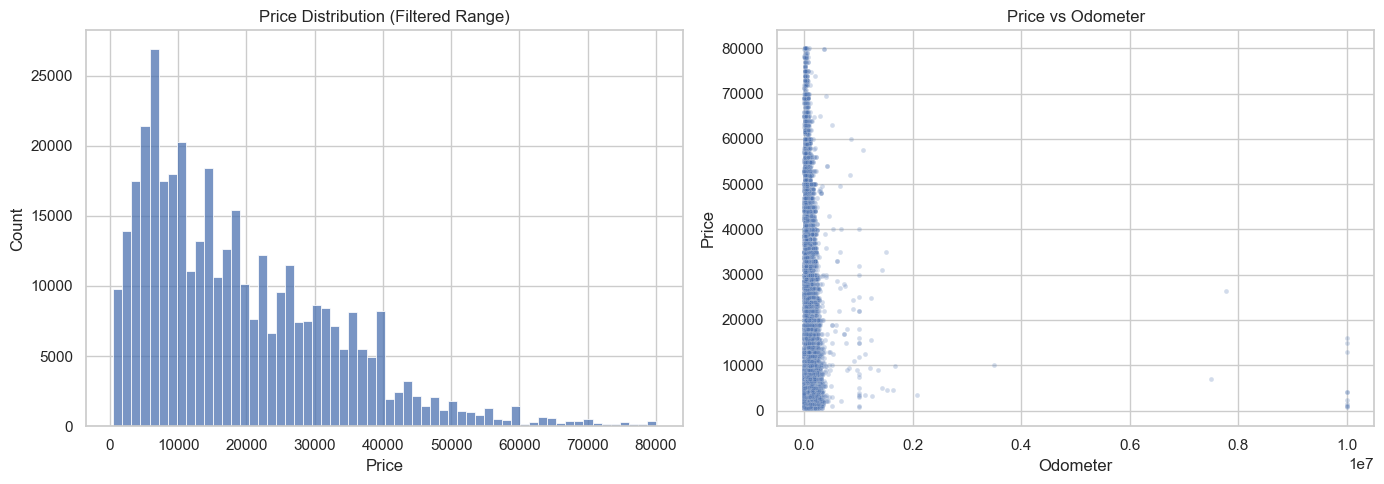

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df.loc[df["price"].between(500, 80000), "price"], bins=60, ax=axes[0])
axes[0].set_title("Price Distribution (Filtered Range)")
axes[0].set_xlabel("Price")

sample = df[df["odometer"].notna() & df["price"].between(500, 80000)].sample(
    n=min(30000, len(df[df["odometer"].notna() & df["price"].between(500, 80000)])),
    random_state=42,
)
sns.scatterplot(data=sample, x="odometer", y="price", s=12, alpha=0.25, ax=axes[1])
axes[1].set_title("Price vs Odometer")
axes[1].set_xlabel("Odometer")
axes[1].set_ylabel("Price")

plt.tight_layout()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [9]:
model_df = df.copy()

# Keep plausible prices and years
model_df = model_df[model_df["price"].between(500, 80000)]
model_df = model_df[model_df["year"].between(1990, 2023)]
model_df = model_df[model_df["odometer"].between(100, 400000)]

# Feature engineering
model_df["age"] = 2024 - model_df["year"]
model_df["log_price"] = np.log1p(model_df["price"])

# Keep moderately frequent manufacturers for robust OHE footprint
top_brands = model_df["manufacturer"].value_counts().head(20).index
model_df["manufacturer_grouped"] = np.where(
    model_df["manufacturer"].isin(top_brands),
    model_df["manufacturer"],
    "other",
)

model_df.shape

(363499, 21)

In [10]:
feature_cols = [
    "age", "odometer", "manufacturer_grouped", "model", "condition",
    "fuel", "title_status", "transmission", "drive", "type", "paint_color", "state"
]

data_for_model = model_df[feature_cols + ["log_price"]].copy()

# Optional sample for runtime control on large dataset
if len(data_for_model) > 120000:
    data_for_model = data_for_model.sample(120000, random_state=42)

X = data_for_model[feature_cols]
y = data_for_model["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((96000, 12), (24000, 12))

In [11]:
numeric_features = ["age", "odometer"]
categorical_features = [c for c in feature_cols if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [12]:
def cv_rmse(model, X_data, y_data, folds):
    scores = cross_val_score(
        model,
        X_data,
        y_data,
        scoring="neg_root_mean_squared_error",
        cv=folds,
        n_jobs=-1,
    )
    return -scores.mean(), scores.std()

linear_pipe = Pipeline(steps=[("prep", preprocessor), ("model", LinearRegression())])
ridge_pipe = Pipeline(steps=[("prep", preprocessor), ("model", Ridge(alpha=10.0))])
lasso_pipe = Pipeline(steps=[("prep", preprocessor), ("model", Lasso(alpha=0.001, max_iter=5000))])
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=250,
        max_depth=20,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    )),
])

candidate_models = {
    "LinearRegression": linear_pipe,
    "Ridge": ridge_pipe,
    "Lasso": lasso_pipe,
    "RandomForest": rf_pipe,
}

In [13]:
cv_results = []

for name, mdl in candidate_models.items():
    mean_rmse, std_rmse = cv_rmse(mdl, X_train, y_train, cv)
    cv_results.append({
        "model": name,
        "cv_rmse_log_price": mean_rmse,
        "cv_std": std_rmse,
    })

cv_df = pd.DataFrame(cv_results).sort_values("cv_rmse_log_price")
cv_df

,model,cv_rmse_log_price,cv_std
3,RandomForest,0.445130,0.006325
0,LinearRegression,0.488175,0.007221
1,Ridge,0.488939,0.007019
2,Lasso,0.523030,0.006432


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [14]:
best_model_name = cv_df.iloc[0]["model"]
best_model = candidate_models[best_model_name]
print(f"Best model by CV RMSE (log-price): {best_model_name}")
cv_df

Best model by CV RMSE (log-price): RandomForest


,model,cv_rmse_log_price,cv_std
3,RandomForest,0.445130,0.006325
0,LinearRegression,0.488175,0.007221
1,Ridge,0.488939,0.007019
2,Lasso,0.523030,0.006432


In [16]:
best_model.fit(X_train, y_train)

pred_log = best_model.predict(X_test)
test_rmse_log = np.sqrt(mean_squared_error(y_test, pred_log))
test_r2_log = r2_score(y_test, pred_log)

# Back-transform for business-scale RMSE
pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_test)
test_rmse_price = np.sqrt(mean_squared_error(actual_price, pred_price))

metrics_df = pd.DataFrame({
    "metric": ["Test RMSE (log-price)", "Test R2 (log-price)", "Test RMSE (price)"],
    "value": [test_rmse_log, test_r2_log, test_rmse_price],
})
metrics_df

,metric,value
0,Test RMSE (log-price),0.439179
1,Test R2 (log-price),0.756553
2,Test RMSE (price),6387.943280


In [17]:
# Feature importance / coefficients
feature_names = best_model.named_steps["prep"].get_feature_names_out()
model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    raw_importance = model_step.feature_importances_
else:
    raw_importance = np.abs(model_step.coef_)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": raw_importance,
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
0,num__age,0.530016
1,num__odometer,0.122828
842,cat__drive_fwd,0.054601
827,cat__fuel_diesel,0.046017
853,cat__type_sedan,0.028836
822,cat__condition_fair,0.015517
829,cat__fuel_gas,0.012634
852,cat__type_pickup,0.009367
854,cat__type_truck,0.006928
820,cat__model_infrequent_sklearn,0.005935


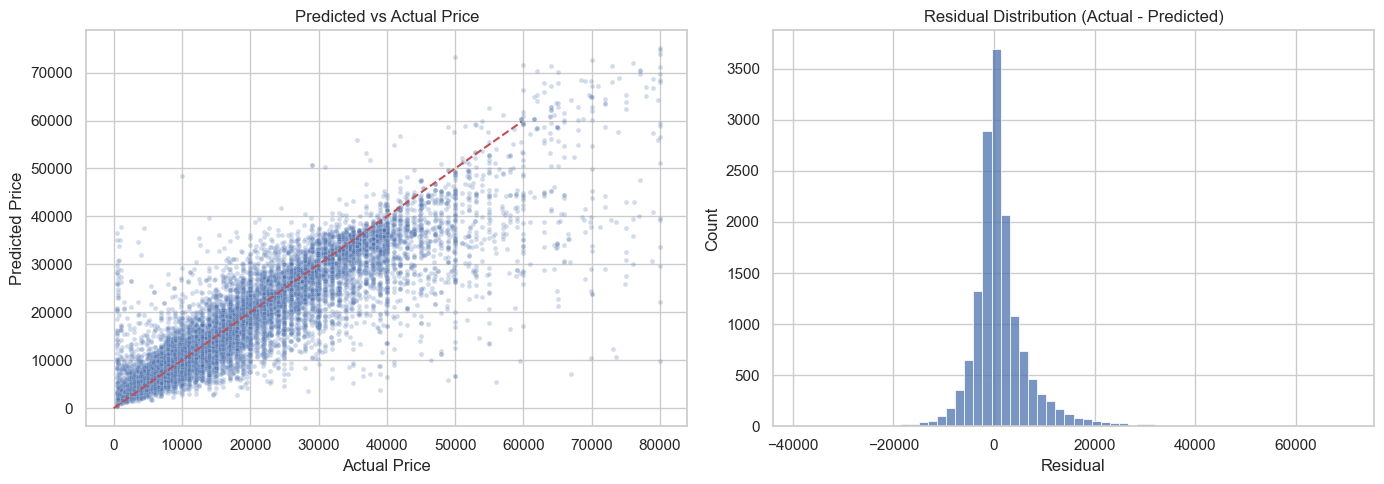

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = pd.DataFrame({"actual": actual_price, "pred": pred_price})
plot_df = plot_df.sample(n=min(15000, len(plot_df)), random_state=42)

sns.scatterplot(data=plot_df, x="actual", y="pred", s=12, alpha=0.25, ax=axes[0])
max_val = np.percentile(plot_df[["actual", "pred"]].values, 99)
axes[0].plot([0, max_val], [0, max_val], "r--")
axes[0].set_title("Predicted vs Actual Price")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

residuals = plot_df["actual"] - plot_df["pred"]
sns.histplot(residuals, bins=60, ax=axes[1])
axes[1].set_title("Residual Distribution (Actual - Predicted)")
axes[1].set_xlabel("Residual")

plt.tight_layout()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [19]:
# Top importance grouped into readable themes
importance_df["theme"] = np.select(
    [
        importance_df["feature"].str.contains("num__age", regex=False),
        importance_df["feature"].str.contains("num__odometer", regex=False),
        importance_df["feature"].str.contains("manufacturer_grouped", regex=False),
        importance_df["feature"].str.contains("transmission", regex=False),
        importance_df["feature"].str.contains("fuel", regex=False),
        importance_df["feature"].str.contains("condition", regex=False),
    ],
    ["Age", "Mileage", "Brand", "Transmission", "Fuel", "Condition"],
    default="Other",
)

theme_impact = (
    importance_df.groupby("theme", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
theme_impact

,theme,importance
0,Age,0.530016
5,Other,0.210078
4,Mileage,0.122828
3,Fuel,0.060655
1,Brand,0.042766
2,Condition,0.027356
6,Transmission,0.006300


In [20]:
brand_price = (
    model_df.groupby("manufacturer")["price"]
    .median()
    .sort_values(ascending=False)
)

brand_count = model_df["manufacturer"].value_counts()
brand_view = pd.concat([brand_count.rename("listings"), brand_price.rename("median_price")], axis=1)
brand_view = brand_view[brand_view["listings"] >= 1000].sort_values("median_price", ascending=False)
brand_view.head(15)

,listings,median_price
manufacturer,,
ram,15844,29999.0
porsche,1125,29997.0
jaguar,1732,28590.0
rover,1840,24996.5
audi,6925,24990.0
gmc,14519,24590.0
infiniti,4379,21590.0
acura,5502,20590.0
lexus,7514,19997.5


In [32]:
transmission_median = model_df.groupby("transmission")["price"].median().sort_values(ascending=False)
fuel_median = model_df.groupby("fuel")["price"].median().sort_values(ascending=False)

display(transmission_median.to_frame("median_price"))
display(fuel_median.to_frame("median_price"))

,median_price
transmission,
other,28590.0
automatic,13000.0
manual,9995.0


,median_price
fuel,
diesel,32500.0
other,27990.0
electric,25590.0
gas,13995.0
hybrid,12995.0


In [22]:
from IPython.display import Markdown

display(Markdown("""
### Business Recommendations
- Prioritize acquisition of **younger, low-mileage** cars.
- Allocate more inventory to **high-resale brands** (e.g., Toyota, Honda where local demand is strong).
- Use **automatic transmission** preference in stocking decisions when market supports premium pricing.
- Deploy the trained model as a **pricing assistant** for purchase and listing decisions.
"""))


### Business Recommendations
- Prioritize acquisition of **younger, low-mileage** cars.
- Allocate more inventory to **high-resale brands** (e.g., Toyota, Honda where local demand is strong).
- Use **automatic transmission** preference in stocking decisions when market supports premium pricing.
- Deploy the trained model as a **pricing assistant** for purchase and listing decisions.


In [23]:
error_df = pd.DataFrame({
    "actual_price": actual_price,
    "pred_price": pred_price,
})
error_df["abs_error"] = (error_df["actual_price"] - error_df["pred_price"]).abs()
error_df["actual_bin"] = pd.qcut(error_df["actual_price"], q=10, duplicates="drop")

error_by_bin = error_df.groupby("actual_bin", observed=False)["abs_error"].mean().to_frame("mean_abs_error")
error_by_bin

,mean_abs_error
actual_bin,
"(499.999, 4100.0]",2840.104079
"(4100.0, 6500.0]",1575.906164
"(6500.0, 8995.0]",2008.769566
"(8995.0, 11995.0]",2538.411346
"(11995.0, 15900.0]",3109.579395
"(15900.0, 19900.0]",3432.566512
"(19900.0, 24995.0]",3686.042532
"(24995.0, 30590.0]",4066.832751
"(30590.0, 37998.0]",4384.619228


In [33]:
display(Markdown(f"""
### Evaluation Summary
- Best model: **{best_model_name}**
- Test RMSE (log-price): **{test_rmse_log:.4f}**
- Test R² (log-price): **{test_r2_log:.4f}**
- Test RMSE (price): **${test_rmse_price:,.0f}**

Key business drivers are age, mileage, and brand effects, with transmission and fuel contributing secondary impact.
"""))


### Evaluation Summary
- Best model: **RandomForest**
- Test RMSE (log-price): **0.4392**
- Test R² (log-price): **0.7566**
- Test RMSE (price): **$6,388**

Key business drivers are age, mileage, and brand effects, with transmission and fuel contributing secondary impact.


### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

In [25]:
import joblib

artifact = {
    "model": best_model,
    "feature_cols": feature_cols,
    "metrics": {
        "test_rmse_log": float(test_rmse_log),
        "test_r2_log": float(test_r2_log),
        "test_rmse_price": float(test_rmse_price),
    },
}

joblib.dump(artifact, "used_car_price_model.joblib")
"Saved: used_car_price_model.joblib"

'Saved: used_car_price_model.joblib'

In [26]:
loaded = joblib.load("used_car_price_model.joblib")
loaded.keys()

dict_keys(['model', 'feature_cols', 'metrics'])

In [27]:
def predict_price(new_data: pd.DataFrame, model_bundle: dict) -> pd.DataFrame:
    mdl = model_bundle["model"]
    cols = model_bundle["feature_cols"]
    pred_log_values = mdl.predict(new_data[cols])
    pred_values = np.expm1(pred_log_values)
    out = new_data.copy()
    out["predicted_price"] = pred_values
    return out

In [28]:
example_rows = X_test.head(5).copy()
predict_price(example_rows, loaded)[["age", "odometer", "manufacturer_grouped", "model", "predicted_price"]]

,age,odometer,manufacturer_grouped,model,predicted_price
116305,14.0,91605.0,honda,cr-v,7966.479439
234614,6.0,72555.0,toyota,4runner,26473.454005
66218,25.0,175000.0,ford,f-350 super duty,3324.516897
271854,16.0,161000.0,dodge,grand caravan,4653.812224
15342,11.0,148541.0,jeep,grand cherokee,11088.557895


In [29]:
# Inventory opportunity scoring: lower predicted value segments can indicate acquisition caution
inventory_view = model_df[feature_cols + ["price"]].sample(n=min(20000, len(model_df)), random_state=42).copy()
inventory_scored = predict_price(inventory_view, loaded)
inventory_scored["pricing_gap"] = inventory_scored["price"] - inventory_scored["predicted_price"]
inventory_scored[["price", "predicted_price", "pricing_gap"]].describe()

,price,predicted_price,pricing_gap
count,20000.000000,20000.000000,20000.000000
mean,18942.229350,17794.898173,1147.331177
std,13723.865693,11752.431844,5431.388013
min,500.000000,500.369466,-40751.400387
25%,7900.000000,7858.777188,-1278.566808
50%,15950.000000,15150.256930,228.013556
75%,27988.000000,26383.277702,2484.506327
max,79999.000000,77275.666323,53987.849047


In [30]:
top_overpriced = inventory_scored.sort_values("pricing_gap", ascending=False).head(10)
top_underpriced = inventory_scored.sort_values("pricing_gap", ascending=True).head(10)

display(Markdown("### Potentially Overpriced Listings (Sample)"))
display(top_overpriced[["manufacturer_grouped", "model", "age", "odometer", "price", "predicted_price", "pricing_gap"]])

display(Markdown("### Potentially Underpriced Listings (Sample)"))
display(top_underpriced[["manufacturer_grouped", "model", "age", "odometer", "price", "predicted_price", "pricing_gap"]])

### Potentially Overpriced Listings (Sample)

,manufacturer_grouped,model,age,odometer,price,predicted_price,pricing_gap
185851,toyota,supra,31.0,147000.0,64000,10012.150953,53987.849047
358457,acura,nsx,33.0,88132.0,79500,26501.912659,52998.087341
51685,mercedes-benz,e-class,6.0,42785.0,79998,30388.720669,49609.279331
319478,ram,3500 laramie,5.0,28851.0,69895,21492.870153,48402.129847
43400,other,sport supercharged,6.0,28000.0,77900,30544.463103,47355.536897
400441,cadillac,escalade esv platinum,5.0,28515.0,79999,33580.216744,46418.783256
101009,other,model x p100d,6.0,6600.0,76100,30112.387972,45987.612028
101635,other,model x p100d,6.0,6400.0,76100,30112.387972,45987.612028
354529,other,maserati granturismo,7.0,28400.0,72900,28456.978591,44443.021409
193993,gmc,sierra 2500hd denalicrew,4.0,1800.0,77261,33108.687430,44152.312570


### Potentially Underpriced Listings (Sample)

,manufacturer_grouped,model,age,odometer,price,predicted_price,pricing_gap
42393,mercedes-benz,sprinter,6.0,40000.0,9950,50701.400387,-40751.400387
405960,jeep,wrangler unlimited maxed,4.0,17771.0,784,37720.344731,-36936.344731
113284,chevrolet,impala,4.0,23000.0,2499,34105.320876,-31606.320876
122319,other,BUY HERE PAY HERE,3.0,1111.0,666,29913.102474,-29247.102474
197209,lexus,es350,7.0,14000.0,1895,29457.856035,-27562.856035
138394,jeep,wrangler unlimited,10.0,54358.0,502,27369.902869,-26867.902869
87473,ram,3500 chassis cab,11.0,321000.0,13999,39757.325851,-25758.325851
324589,bmw,x5,7.0,61732.0,557,26171.575896,-25614.575896
183066,other,g35,7.0,42000.0,500,25724.982322,-25224.982322
295992,other,encore essence,5.0,27271.0,2000,26827.497098,-24827.497098


In [34]:
display(Markdown("""
## Final Client-Facing Summary
1. **Strongest price drivers** are car age, mileage, and manufacturer effects.
2. **Automatic transmission** and selected fuel/condition categories contribute additional signal.
3. The selected model can support **pricing consistency** and **inventory optimization**.
4. Recommended next step: retrain monthly and include region-specific demand features for higher accuracy.
"""))


## Final Client-Facing Summary
1. **Strongest price drivers** are car age, mileage, and manufacturer effects.
2. **Automatic transmission** and selected fuel/condition categories contribute additional signal.
3. The selected model can support **pricing consistency** and **inventory optimization**.
4. Recommended next step: retrain monthly and include region-specific demand features for higher accuracy.
